# 4. CHẠY MÔ HÌNH PRETRAINED (INFERENCE)

## 4.1 PyTorch (torchvision)

Device: cpu
Directory: ../assets/images
Total images: 4

Image 1: image copy 2.png - Detected 2 object(s)
  + dog: 0.9756 | Box: [48.6, 83.2, 178.0, 274.0]
  + bird: 0.5089 | Box: [0.0, 216.6, 233.3, 349.7]


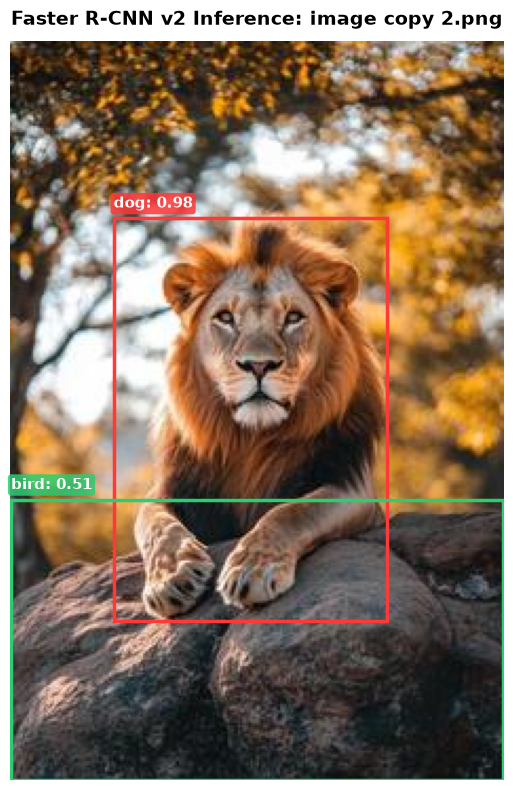


Image 2: image copy 3.png - Detected 1 object(s)
  + cat: 0.9949 | Box: [2.7, 72.1, 777.6, 1270.7]


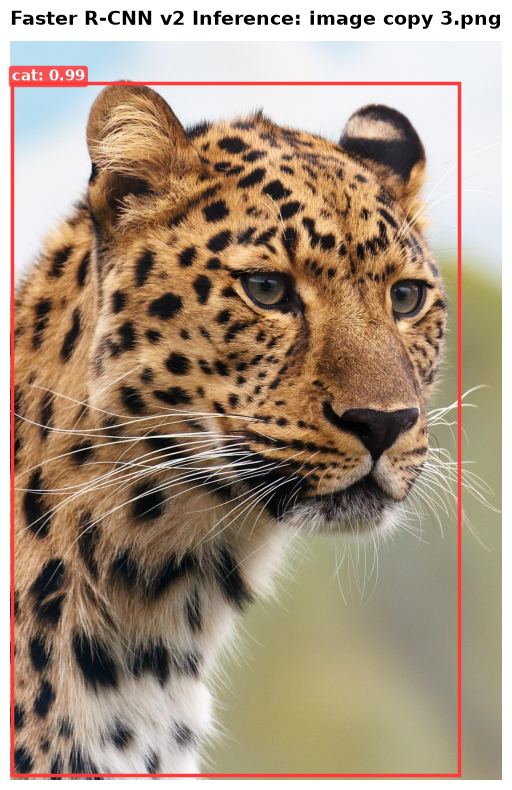


Image 3: image copy.png - Detected 1 object(s)
  + zebra: 0.9993 | Box: [75.3, 40.1, 328.8, 248.3]


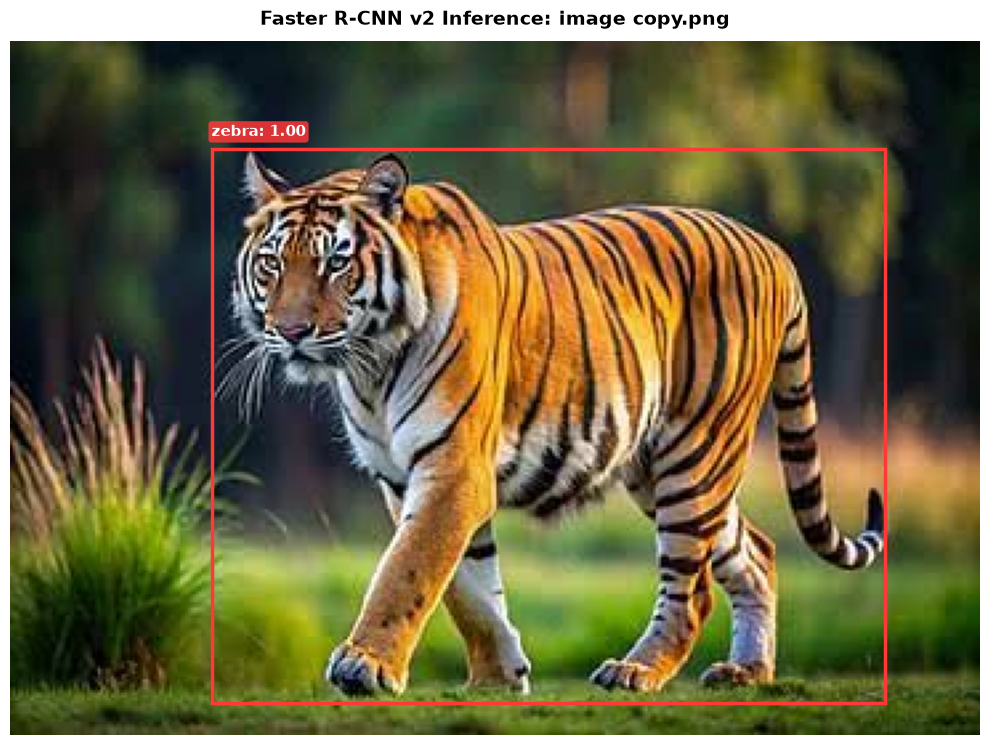


Image 4: image.png - Detected 1 object(s)
  + bird: 0.9987 | Box: [49.9, 149.5, 494.0, 729.0]


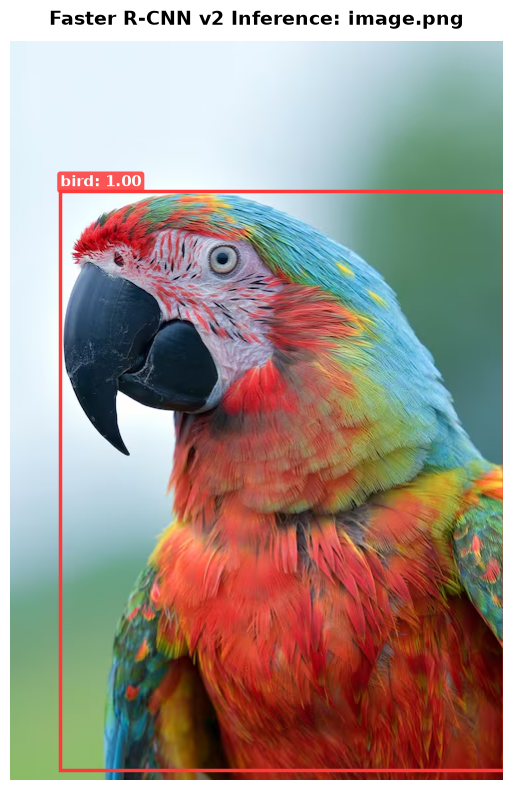

In [1]:
import os
import torch
import torchvision
from torchvision.transforms import functional as F
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = torchvision.models.detection.FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(weights=weights).to(device).eval()
categories = weights.meta["categories"]

possible_dirs = [
    "/content/images",
    "../assets/images",
    "./assets/images",
    os.path.join(os.getcwd(), "assets/images"),
    os.path.join(os.getcwd(), "Lab04_two_stages/assets/images"),
    os.path.join(os.getcwd(), "../assets/images")
]

image_dir = next((d for d in possible_dirs if os.path.exists(d) and any(f.lower().endswith((".png", ".jpg", ".jpeg")) for f in os.listdir(d))), None)

if image_dir is not None:
    image_names = sorted([f for f in os.listdir(image_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
    print(f"Device: {device}")
    print(f"Directory: {image_dir}")
    print(f"Total images: {len(image_names)}")

    colors = ["#FF3838", "#2ECC71", "#3498DB", "#9B59B6", "#F1C40F", "#E67E22"]

    for idx, name in enumerate(image_names):
        image_path = os.path.join(image_dir, name)
        pil_image = Image.open(image_path).convert("RGB")
        image_tensor = F.to_tensor(pil_image).unsqueeze(0).to(device)

        with torch.no_grad():
            predictions = model(image_tensor)[0]

        boxes = predictions["boxes"].cpu()
        scores = predictions["scores"].cpu()
        labels = predictions["labels"].cpu()

        keep_indices = scores >= 0.5
        filtered_boxes = boxes[keep_indices]
        filtered_scores = scores[keep_indices]
        filtered_labels = labels[keep_indices]

        print(f"\nImage {idx + 1}: {name} - Detected {len(filtered_boxes)} object(s)")

        fig, ax = plt.subplots(1, figsize=(10, 8))
        ax.imshow(pil_image)

        for b_idx, (box, score, label) in enumerate(zip(filtered_boxes, filtered_scores, filtered_labels)):
            x1, y1, x2, y2 = box.tolist()
            width = x2 - x1
            height = y2 - y1
            class_name = categories[label.item()]
            color = colors[b_idx % len(colors)]

            rect = patches.Rectangle((x1, y1), width, height, linewidth=2.5, edgecolor=color, facecolor="none")
            ax.add_patch(rect)

            label_text = f"{class_name}: {score.item():.2f}"
            ax.text(x1, max(y1 - 5, 0), label_text, color="white", fontsize=11, fontweight="bold",
                    bbox=dict(facecolor=color, alpha=0.85, edgecolor="none", boxstyle="round,pad=0.2"))
            print(f"  + {class_name}: {score.item():.4f} | Box: [{x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f}]")

        ax.axis("off")
        ax.set_title(f"Faster R-CNN v2 Inference: {name}", fontsize=14, fontweight="bold", pad=12)
        plt.tight_layout()
        plt.show()

**Nhận xét**

Mô hình Faster R-CNN ResNet-50 FPN v2 với trọng số pretrained trên tập COCO có khả năng phát hiện và khoanh vùng đối tượng với độ chính xác cao về mặt vị trí bounding box trên các ảnh thực tế.

Tuy nhiên, do tập dữ liệu huấn luyện COCO chỉ có 80 lớp đối tượng thông thường và không có các loài như sư tử, báo hay hổ, mô hình buộc phải gán nhãn dự đoán về lớp gần nhất trong danh sách đã học. Báo được phân loại thành mèo do cùng thuộc họ mèo, sư tử được phân loại thành chó do tương đồng một số đặc điểm hình thái, và hổ được phân loại thành ngựa vằn do các đường vằn trên cơ thể. Đối với ảnh chim vẹt, mô hình dự đoán chính xác lớp chim do nhãn này có sẵn trong tập COCO.

Điều này cho thấy mô hình pretrained có khả năng định vị vật thể tốt nhưng bị giới hạn bởi không gian nhãn ban đầu khi gặp các đối tượng ngoài miền dữ liệu. Để mô hình có thể nhận diện chính xác các loài vật mới, việc fine-tune và huấn luyện lại trên tập dữ liệu đặc thù ở các bước tiếp theo là rất cần thiết.